# Process Mining with Python and PM4Py
## A fictional investment-banking booking process — Complete solutions

**Duration:** 60 minutes &nbsp; | &nbsp; **Level:** Intermediate Python, new to process mining

> **Fictional-data notice:** Every trade, counterparty, resource, and event in this workshop is synthetic.
> An anomaly is a reason to investigate—not proof of error or misconduct.

## Learning objectives and agenda

By the end, you will be able to:

1. explain what process mining adds to ordinary reporting;
2. recognize and prepare a case-based event log;
3. discover and visualize control flow and performance with PM4Py;
4. find suspicious cases with rare variants, duration, and conformance diagnostics.

| Time | Topic |
|---:|---|
| 0–8 min | What process mining is |
| 8–20 min | Load and prepare an event log |
| 20–40 min | Discover and visualize the process |
| 40–56 min | Find and explain outliers |
| 56–60 min | Recap and next steps |

In [2]:
from pathlib import Path
import shutil
import tempfile

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pm4py
from IPython.display import SVG, display

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)

CASE_ID = "case:concept:name"
ACTIVITY = "concept:name"
TIMESTAMP = "time:timestamp"

print("PM4Py version:", pm4py.__version__)
print("Graphviz dot available:", shutil.which("dot") is not None)

PM4Py version: 2.7.22
Graphviz dot available: False


# 1. What is process mining? (0–8 minutes)

A business process is not just a flowchart: it is what cases actually did over time. **Process mining**
reconstructs and measures that behavior from event data.

Every useful event log needs three essential ideas:

- **Case:** one process instance, such as one booking ID.
- **Activity:** a step performed for the case, such as `Compliance Check`.
- **Timestamp:** when that step occurred.

Optional attributes—resource, desk, product, amount, or counterparty tier—help explain *why* behavior differs.

The three common process-mining questions are:

- **Discovery:** What process does the data reveal?
- **Performance:** Where are delays, queues, or rework?
- **Conformance:** Which cases deviate from expected behavior?

Traditional BI usually aggregates rows into totals. Process mining retains the **sequence within each case**,
which exposes loops, skipped controls, premature steps, and alternative paths.

### Quick check: which table is an event log?

**A.** One row per desk with monthly trade count and average value.  
**B.** One row per booking event with booking ID, activity, and timestamp.  
**C.** One row per employee with team and job title.

<details><summary>Reveal the answer</summary>

**B.** It preserves the case, activity, and time needed to reconstruct each trace. A and C may enrich an
analysis, but cannot reconstruct a process by themselves.
</details>

### Scenario

A fictional investment bank wants to understand its post-trade booking process. A normal booking may include:

`Trade Captured → Validate Economics → Enrich Counterparty → Compliance Check → Credit Check →`
`[Supervisor Approval for high-value trades] → Confirm Booking → Post to Ledger → Booking Complete`

Some legitimate cases require one amendment and revalidation. We will inspect 120 historical baseline cases
and 40 later monitoring cases.

**Predict before coding:** Where would you expect rework, delays, or control failures to appear?

# 2. Load and prepare the event log (8–20 minutes)

The CSV deliberately contains no anomaly label. In real work, the point is to find behavior worth reviewing
before an investigator confirms what happened.

### Your turn 1 — load and inspect

Load the CSV, parse the timestamp column, and show the first five rows.

In [3]:
DATA_PATH = Path("data/investment_banking_booking_log.csv")
raw_log = pd.read_csv(DATA_PATH, parse_dates=[TIMESTAMP])
raw_log.head()

,case:concept:name,concept:name,time:timestamp,org:resource,booking_period,desk,product,currency,counterparty_tier,notional_usd
0,BK-0001,Trade Captured,2026-01-05 08:00:00+00:00,trader_02,baseline,FX,FX Forward,EUR,Tier 1,42238000.0
1,BK-0001,Validate Economics,2026-01-05 08:11:00+00:00,ops_analyst_03,baseline,FX,FX Forward,EUR,Tier 1,42238000.0
2,BK-0001,Enrich Counterparty,2026-01-05 08:25:00+00:00,static_data_01,baseline,FX,FX Forward,EUR,Tier 1,42238000.0
3,BK-0001,Compliance Check,2026-01-05 08:39:00+00:00,compliance_02,baseline,FX,FX Forward,EUR,Tier 1,42238000.0
4,BK-0001,Credit Check,2026-01-05 08:52:00+00:00,credit_02,baseline,FX,FX Forward,EUR,Tier 1,42238000.0


### Data contract

| Column | Meaning |
|---|---|
| `case:concept:name` | Booking/case identifier |
| `concept:name` | Activity name |
| `time:timestamp` | UTC event timestamp |
| `org:resource` | Fictional person or system performing the event |
| `booking_period` | `baseline` or `monitoring` cohort |
| `desk`, `product`, `currency` | Trade dimensions |
| `counterparty_tier`, `notional_usd` | Case context repeated on each event |

### Your turn 2 — validate the minimum event-log quality

Calculate row count, case count, activity count, missing values in required columns, and whether timestamps
increase within every case.

In [4]:
required = [CASE_ID, ACTIVITY, TIMESTAMP]
quality = {
    "events": len(raw_log),
    "cases": raw_log[CASE_ID].nunique(),
    "activities": raw_log[ACTIVITY].nunique(),
    "missing_required_values": int(raw_log[required].isna().sum().sum()),
    "all_cases_time_ordered": bool(
        raw_log.groupby(CASE_ID)[TIMESTAMP].apply(lambda s: s.is_monotonic_increasing).all()
    ),
}
pd.Series(quality, name="value")

events                     1380
cases                       160
activities                   11
missing_required_values       0
all_cases_time_ordered     True
Name: value, dtype: object

PM4Py accepts a pandas DataFrame when the case, activity, and timestamp keys are supplied. Formatting makes
the types and ordering explicit. We retain business attributes for later slicing and interpretation.

In [5]:
log = pm4py.format_dataframe(
    raw_log,
    case_id=CASE_ID,
    activity_key=ACTIVITY,
    timestamp_key=TIMESTAMP,
).sort_values([CASE_ID, TIMESTAMP], kind="stable")

baseline = log.loc[log["booking_period"].eq("baseline")].copy()
monitoring = log.loc[log["booking_period"].eq("monitoring")].copy()

print("Baseline cases:", baseline[CASE_ID].nunique())
print("Monitoring cases:", monitoring[CASE_ID].nunique())

Baseline cases: 120
Monitoring cases: 40


### Your turn 3 — summarize cases and durations

Build one row per case with start time, end time, event count, cohort, and duration in minutes. Then compare
median duration by cohort.

In [6]:
case_summary = (
    log.groupby(CASE_ID)
    .agg(
        start_time=(TIMESTAMP, "min"),
        end_time=(TIMESTAMP, "max"),
        event_count=(ACTIVITY, "size"),
        booking_period=("booking_period", "first"),
    )
    .reset_index()
)
case_summary["duration_minutes"] = (
    case_summary["end_time"] - case_summary["start_time"]
).dt.total_seconds() / 60

display(case_summary.head())
case_summary.groupby("booking_period")["duration_minutes"].agg(["count", "median", "max"])

,case:concept:name,start_time,end_time,event_count,booking_period,duration_minutes
0,BK-0001,2026-01-05 08:00:00+00:00,2026-01-05 09:27:00+00:00,8,baseline,87.0
1,BK-0002,2026-01-05 10:00:00+00:00,2026-01-05 11:28:00+00:00,8,baseline,88.0
2,BK-0003,2026-01-05 12:00:00+00:00,2026-01-05 13:45:00+00:00,10,baseline,105.0
3,BK-0004,2026-01-05 14:00:00+00:00,2026-01-05 15:20:00+00:00,8,baseline,80.0
4,BK-0005,2026-01-06 08:00:00+00:00,2026-01-06 09:50:00+00:00,10,baseline,110.0


,count,median,max
booking_period,,,
baseline,120,91.0,157.0
monitoring,40,92.0,4415.0


# 3. Discover and visualize the process (20–40 minutes)

A **trace** is the ordered activity sequence of one case. A **variant** is a distinct trace shared by one or
more cases. Variant frequency gives a compact view of the process's dominant and unusual routes.

### Your turn 4 — extract variants

Create an activity tuple for every case, count the tuples, and display the ten most frequent variants.

In [7]:
variant_by_case = (
    log.sort_values([CASE_ID, TIMESTAMP])
    .groupby(CASE_ID)[ACTIVITY]
    .agg(tuple)
    .rename("variant")
)
variant_counts = variant_by_case.value_counts().rename_axis("variant").reset_index(name="case_count")
variant_counts.head(10)

,variant,case_count
0,"(Trade Captured, Validate Economics, Enrich Counterparty, Compliance Check, Credit Check, Confirm Booking, Post to L...",111
1,"(Trade Captured, Validate Economics, Amend Booking, Validate Economics, Enrich Counterparty, Compliance Check, Credi...",21
2,"(Trade Captured, Validate Economics, Enrich Counterparty, Compliance Check, Credit Check, Supervisor Approval, Confi...",10
3,"(Trade Captured, Validate Economics, Amend Booking, Validate Economics, Enrich Counterparty, Compliance Check, Credi...",6
4,"(Trade Captured, Validate Economics, Enrich Counterparty, Credit Check, Supervisor Approval, Confirm Booking, Post t...",3
5,"(Trade Captured, Validate Economics, Enrich Counterparty, Compliance Check, Credit Check, Post to Ledger, Supervisor...",3
6,"(Trade Captured, Validate Economics, Amend Booking, Validate Economics, Amend Booking, Validate Economics, Amend Boo...",3
7,"(Trade Captured, Validate Economics, Enrich Counterparty, Compliance Check, Manual Override, Credit Check, Confirm B...",3


**Interpretation prompt:** Is the most common route the only valid route? Which optional step or loop explains
the main alternatives? A rare route is a useful signal, but rarity alone is not a control failure.

A **Directly-Follows Graph (DFG)** counts adjacent activity pairs across cases. A frequency DFG shows what
happens often; a performance DFG shows elapsed time between adjacent activities.

In [8]:
def draw_dfg(dfg, start_activities, end_activities, title, performance=False, max_edges=18):
    """Render through PM4Py/Graphviz when available, otherwise use a notebook-safe fallback."""
    if shutil.which("dot"):
        output = Path(tempfile.mkdtemp()) / "dfg.svg"
        if performance:
            pm4py.save_vis_performance_dfg(
                dfg, start_activities, end_activities, str(output),
                rankdir="LR", graph_title=title, max_num_edges=max_edges,
            )
        else:
            pm4py.save_vis_dfg(
                dfg, start_activities, end_activities, str(output),
                rankdir="LR", graph_title=title, max_num_edges=max_edges,
            )
        display(SVG(filename=str(output)))
        return

    def metric_value(value):
        if isinstance(value, dict):
            return float(value.get("mean", next(iter(value.values()))))
        return float(value)

    strongest = sorted(
        dfg.items(), key=lambda item: metric_value(item[1]), reverse=True
    )[:max_edges]
    graph = nx.DiGraph()
    for (source, target), value in strongest:
        graph.add_edge(source, target, weight=metric_value(value))
    process_positions = {
        "Trade Captured": (0, 0),
        "Validate Economics": (1, 0),
        "Amend Booking": (1, 1),
        "Enrich Counterparty": (2, 0),
        "Compliance Check": (3, 0),
        "Manual Override": (3.5, 1),
        "Credit Check": (4, 0),
        "Supervisor Approval": (5, 1),
        "Confirm Booking": (5, 0),
        "Post to Ledger": (6, 0),
        "Booking Complete": (7, 0),
    }
    positions = {
        node: process_positions.get(node, (index, -1))
        for index, node in enumerate(graph.nodes)
    }
    plt.figure(figsize=(15, 5.5))
    nx.draw_networkx(
        graph, positions, node_color="#dbeafe", edge_color="#64748b",
        node_size=2300, font_size=8, arrowsize=18,
        connectionstyle="arc3,rad=0.06",
    )
    labels = {
        edge: (
            f"{metric_value(value) / 60:.1f}m"
            if performance else f"{int(metric_value(value))}"
        )
        for edge, value in strongest
    }
    nx.draw_networkx_edge_labels(
        graph, positions, edge_labels=labels, font_size=7,
        connectionstyle="arc3,rad=0.06",
    )
    plt.xlim(-0.6, 7.6)
    plt.ylim(-0.65, 1.65)
    plt.title(title + " (NetworkX fallback)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

### Your turn 5 — discover the frequency DFG

Use `pm4py.discover_dfg` on the full log, then visualize it. Before running the cell, predict which edge will
have the highest frequency.

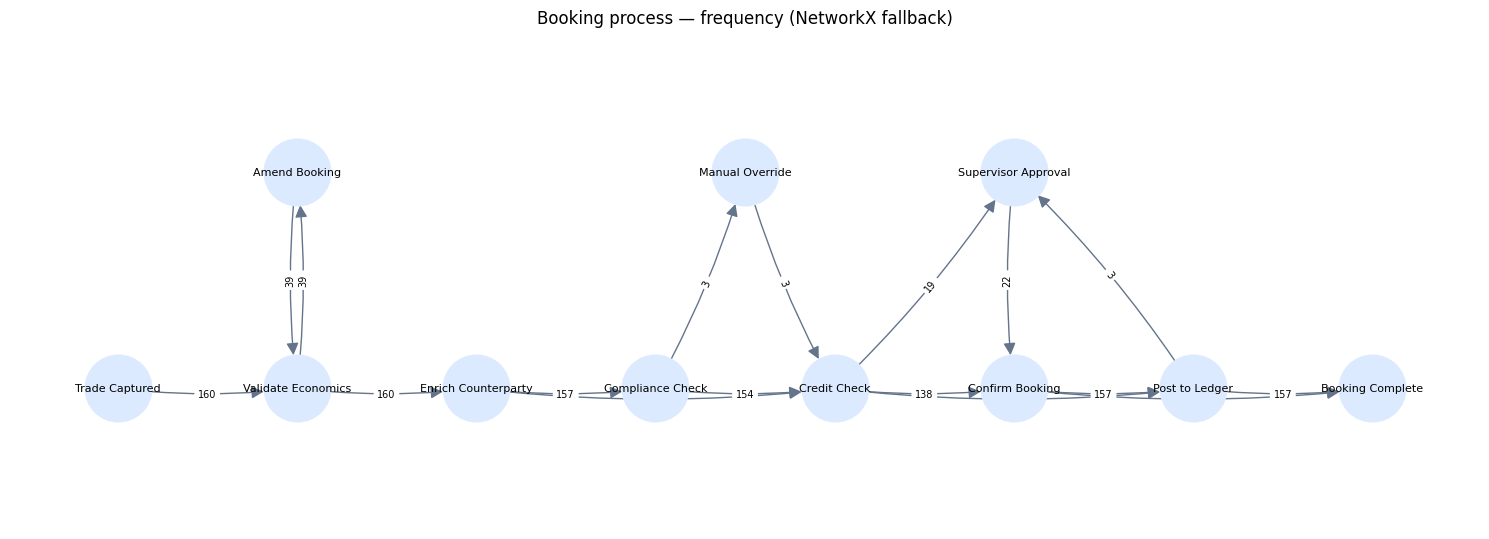

In [9]:
dfg, start_activities, end_activities = pm4py.discover_dfg(
    log,
    activity_key=ACTIVITY,
    timestamp_key=TIMESTAMP,
    case_id_key=CASE_ID,
)
draw_dfg(dfg, start_activities, end_activities, "Booking process — frequency")

### Your turn 6 — discover the performance DFG

Repeat the discovery with `pm4py.discover_performance_dfg`. Edge labels are mean elapsed times. Which edge
looks slow, and is it slow for every case or only a few?

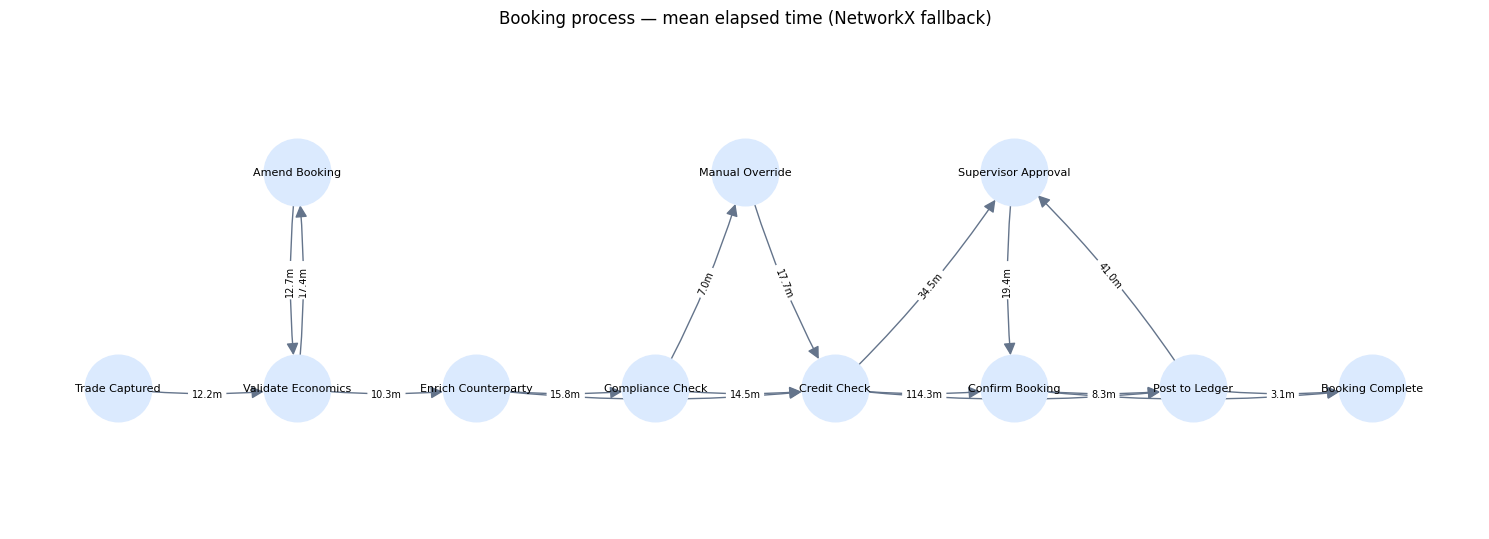

In [10]:
performance_dfg, performance_starts, performance_ends = pm4py.discover_performance_dfg(
    log,
    activity_key=ACTIVITY,
    timestamp_key=TIMESTAMP,
    case_id_key=CASE_ID,
)
draw_dfg(
    performance_dfg, performance_starts, performance_ends,
    "Booking process — mean elapsed time", performance=True,
)

A DFG is descriptive. For formal conformance diagnostics, we discover a Petri net from the known-clean
baseline cohort using the **Inductive Miner**. The same discovery also produces a readable process tree.

### Your turn 7 — discover a reference model

In [11]:
process_tree = pm4py.discover_process_tree_inductive(
    baseline, noise_threshold=0.0,
    activity_key=ACTIVITY, timestamp_key=TIMESTAMP, case_id_key=CASE_ID,
)
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(
    baseline, noise_threshold=0.0,
    activity_key=ACTIVITY, timestamp_key=TIMESTAMP, case_id_key=CASE_ID,
)

if shutil.which("dot"):
    tree_path = Path(tempfile.mkdtemp()) / "process_tree.svg"
    pm4py.save_vis_process_tree(process_tree, str(tree_path), rankdir="LR")
    display(SVG(filename=str(tree_path)))
else:
    print("Discovered process tree (text view):")
    print(process_tree)

Discovered process tree (text view):
->( 'Trade Captured', *( 'Validate Economics', 'Amend Booking' ), 'Enrich Counterparty', 'Compliance Check', 'Credit Check', X( tau, 'Supervisor Approval' ), 'Confirm Booking', 'Post to Ledger', 'Booking Complete' )


# 4. Find outliers with three complementary signals (40–56 minutes)

No single anomaly rule is sufficient:

- **Rare variant:** good for unusual routes, but can flag legitimate rare work.
- **Long duration:** good for delay, but misses fast control violations.
- **Low conformance fitness:** good for unexpected order or activities, but may accept unusual repetitions if
  the reference model contains a loop.

We will flag a monitoring case when **any** signal fires, then preserve the reasons for human review.

### Signal 1 — rare monitoring variants

For this small teaching log, define rare as at most three monitoring cases. In production this threshold
should be calibrated against volume, seasonality, and investigation capacity.

In [12]:
monitoring_case_variants = (
    monitoring.sort_values([CASE_ID, TIMESTAMP])
    .groupby(CASE_ID)[ACTIVITY]
    .agg(tuple)
    .rename("variant")
)
monitoring_variant_frequency = monitoring_case_variants.value_counts()
monitoring_variants = monitoring_case_variants.to_frame()
monitoring_variants["variant_frequency"] = monitoring_variants["variant"].map(monitoring_variant_frequency)
monitoring_variants["rare_variant"] = monitoring_variants["variant_frequency"].le(3)
monitoring_variants.sort_values(["rare_variant", "variant_frequency"], ascending=[False, True]).head(10)

,variant,variant_frequency,rare_variant
case:concept:name,,,
BK-0140,"(Trade Captured, Validate Economics, Enrich Counterparty, Compliance Check, Credit Check, Supervisor Approval, Confi...",1,True
BK-0146,"(Trade Captured, Validate Economics, Amend Booking, Validate Economics, Enrich Counterparty, Compliance Check, Credi...",1,True
BK-0123,"(Trade Captured, Validate Economics, Enrich Counterparty, Credit Check, Supervisor Approval, Confirm Booking, Post t...",3,True
BK-0124,"(Trade Captured, Validate Economics, Enrich Counterparty, Credit Check, Supervisor Approval, Confirm Booking, Post t...",3,True
BK-0127,"(Trade Captured, Validate Economics, Enrich Counterparty, Compliance Check, Credit Check, Post to Ledger, Supervisor...",3,True
BK-0133,"(Trade Captured, Validate Economics, Amend Booking, Validate Economics, Amend Booking, Validate Economics, Amend Boo...",3,True
BK-0135,"(Trade Captured, Validate Economics, Amend Booking, Validate Economics, Enrich Counterparty, Compliance Check, Credi...",3,True
BK-0139,"(Trade Captured, Validate Economics, Enrich Counterparty, Credit Check, Supervisor Approval, Confirm Booking, Post t...",3,True
BK-0141,"(Trade Captured, Validate Economics, Enrich Counterparty, Compliance Check, Manual Override, Credit Check, Confirm B...",3,True


### Signal 2 — unusually long duration

Learn a robust upper bound from baseline duration: `Q3 + 1.5 × IQR`. This avoids using planted labels and is
less sensitive to a few large values than mean plus standard deviation.

In [13]:
baseline_durations = case_summary.loc[
    case_summary["booking_period"].eq("baseline"), "duration_minutes"
]
q1, q3 = baseline_durations.quantile([0.25, 0.75])
iqr = q3 - q1
duration_upper_bound = q3 + 1.5 * iqr

duration_signals = case_summary.loc[
    case_summary["booking_period"].eq("monitoring"),
    [CASE_ID, "duration_minutes"],
].copy()
duration_signals["duration_outlier"] = duration_signals["duration_minutes"].gt(duration_upper_bound)
print(f"Baseline duration upper bound: {duration_upper_bound:.1f} minutes")
duration_signals.sort_values("duration_minutes", ascending=False).head(10)

Baseline duration upper bound: 141.0 minutes


,case:concept:name,duration_minutes,duration_outlier
146,BK-0147,4415.0,True
149,BK-0150,4412.0,True
155,BK-0156,4396.0,True
147,BK-0148,213.0,True
132,BK-0133,190.0,True
151,BK-0152,180.0,True
145,BK-0146,177.0,True
158,BK-0159,145.0,True
153,BK-0154,123.0,False
138,BK-0139,122.0,False


### Signal 3 — conformance fitness

An alignment compares an observed trace with the reference Petri net. A fitness of `1.0` means the trace can
be replayed perfectly. Lower fitness indicates moves present only in the log or only in the model.

**Prediction:** Will an excessive number of repetitions always have low fitness when the model contains a loop?

In [14]:
monitoring_event_log = pm4py.convert_to_event_log(
    monitoring,
    case_id_key=CASE_ID,
)
alignment_results = pm4py.conformance_diagnostics_alignments(
    monitoring_event_log,
    net,
    initial_marking,
    final_marking,
    multi_processing=False,
    return_diagnostics_dataframe=False,
)
alignment_scores = pd.DataFrame(
    {
        CASE_ID: [trace.attributes["concept:name"] for trace in monitoring_event_log],
        "alignment_fitness": [result["fitness"] for result in alignment_results],
        "alignment_cost": [result["cost"] for result in alignment_results],
    }
)
alignment_scores["conformance_outlier"] = alignment_scores["alignment_fitness"].lt(0.999999)
alignment_scores.sort_values(["alignment_fitness", CASE_ID]).head(10)

p:\Alan\Github\ProcessMiner101\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
aligning log, completed variants ::   0%|          | 0/8 [00:00<?, ?it/s]

aligning log, completed variants :: 100%|██████████| 8/8 [00:00<00:00, 535.20it/s]


,case:concept:name,alignment_fitness,alignment_cost,conformance_outlier
6,BK-0127,0.882353,20000,True
28,BK-0149,0.882353,20000,True
38,BK-0159,0.882353,20000,True
2,BK-0123,0.937500,10000,True
3,BK-0124,0.937500,10000,True
18,BK-0139,0.937500,10000,True
20,BK-0141,0.941176,10001,True
23,BK-0144,0.941176,10001,True
36,BK-0157,0.941176,10001,True
0,BK-0121,1.000000,1,False


### Your turn 8 — combine and rank the evidence

Join the three case-level signals. Create a readable `anomaly_reasons` field and rank flagged cases by number
of signals, then by lowest fitness and longest duration.

In [15]:
case_signals = (
    monitoring_variants.reset_index()
    .merge(duration_signals, on=CASE_ID, validate="one_to_one")
    .merge(alignment_scores, on=CASE_ID, validate="one_to_one")
)

signal_columns = ["rare_variant", "duration_outlier", "conformance_outlier"]
case_signals["signal_count"] = case_signals[signal_columns].sum(axis=1)
case_signals["is_anomaly"] = case_signals["signal_count"].gt(0)

def reasons(row):
    labels = []
    if row["rare_variant"]:
        labels.append("rare variant")
    if row["duration_outlier"]:
        labels.append("long duration")
    if row["conformance_outlier"]:
        labels.append("low conformance")
    return ", ".join(labels) if labels else "none"

case_signals["anomaly_reasons"] = case_signals.apply(reasons, axis=1)
ranked_outliers = case_signals.loc[case_signals["is_anomaly"]].sort_values(
    ["signal_count", "alignment_fitness", "duration_minutes"],
    ascending=[False, True, False],
)
ranked_outliers[
    [CASE_ID, "variant_frequency", "duration_minutes", "alignment_fitness",
     "signal_count", "anomaly_reasons"]
].head(20)

,case:concept:name,variant_frequency,duration_minutes,alignment_fitness,signal_count,anomaly_reasons
38,BK-0159,3,145.0,0.882353,3,"rare variant, long duration, low conformance"
28,BK-0149,3,117.0,0.882353,2,"rare variant, low conformance"
6,BK-0127,3,103.0,0.882353,2,"rare variant, low conformance"
18,BK-0139,3,122.0,0.937500,2,"rare variant, low conformance"
2,BK-0123,3,90.0,0.937500,2,"rare variant, low conformance"
3,BK-0124,3,90.0,0.937500,2,"rare variant, low conformance"
20,BK-0141,3,99.0,0.941176,2,"rare variant, low conformance"
36,BK-0157,3,95.0,0.941176,2,"rare variant, low conformance"
23,BK-0144,3,73.0,0.941176,2,"rare variant, low conformance"
27,BK-0148,3,213.0,1.000000,2,"rare variant, long duration"


### Investigate before judging

Pick two flagged booking IDs and inspect their ordered traces. Explain in plain business language what looks
unusual. Then inspect one unflagged case as a comparison.

In [16]:
cases_to_review = ranked_outliers[CASE_ID].head(2).tolist()
normal_comparison = case_signals.loc[~case_signals["is_anomaly"], CASE_ID].head(1).tolist()
cases_to_review += normal_comparison
log.loc[
    log[CASE_ID].isin(cases_to_review),
    [CASE_ID, ACTIVITY, TIMESTAMP, "org:resource"],
].sort_values([CASE_ID, TIMESTAMP])

,case:concept:name,concept:name,time:timestamp,org:resource
1020,BK-0121,Trade Captured,2026-05-04 08:00:00+00:00,trader_03
1021,BK-0121,Validate Economics,2026-05-04 08:16:00+00:00,ops_analyst_03
1022,BK-0121,Enrich Counterparty,2026-05-04 08:23:00+00:00,static_data_01
1023,BK-0121,Compliance Check,2026-05-04 08:31:00+00:00,compliance_01
1024,BK-0121,Credit Check,2026-05-04 08:43:00+00:00,credit_01
1025,BK-0121,Confirm Booking,2026-05-04 08:56:00+00:00,confirmations_01
1026,BK-0121,Post to Ledger,2026-05-04 09:03:00+00:00,ledger_bot_01
1027,BK-0121,Booking Complete,2026-05-04 09:05:00+00:00,workflow_bot_01
1269,BK-0149,Trade Captured,2026-05-11 08:00:00+00:00,trader_01
1270,BK-0149,Validate Economics,2026-05-11 08:11:00+00:00,ops_analyst_03


### Validate against planted truth

During real investigations, ground truth comes from source records and domain experts. For this synthetic
lesson only, the instructor answer key lets us measure precision, recall, and coverage by anomaly type.

In [17]:
answer_key = pd.read_csv(Path("data/instructor_outlier_answer_key.csv"))
detected_ids = set(case_signals.loc[case_signals["is_anomaly"], CASE_ID])
truth_ids = set(answer_key[CASE_ID])

true_positives = len(detected_ids & truth_ids)
false_positives = len(detected_ids - truth_ids)
false_negatives = len(truth_ids - detected_ids)
precision = true_positives / len(detected_ids) if detected_ids else 0.0
recall = true_positives / len(truth_ids) if truth_ids else 0.0

evaluation = pd.Series(
    {
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "precision": precision,
        "recall": recall,
    },
    name="result",
)
display(evaluation)

coverage = answer_key.assign(
    detected=answer_key[CASE_ID].isin(detected_ids)
).groupby("planted_anomaly")["detected"].agg(["sum", "count", "all"])
display(coverage)

answer_key.merge(
    case_signals[[CASE_ID, "anomaly_reasons", "duration_minutes", "alignment_fitness"]],
    on=CASE_ID,
    how="left",
).sort_values(["planted_anomaly", CASE_ID])

true_positives     15.00
false_positives     5.00
false_negatives     0.00
precision           0.75
recall              1.00
Name: result, dtype: float64

,sum,count,all
planted_anomaly,,,
excessive_rework,3,3,True
extreme_delay,3,3,True
premature_ledger_posting,3,3,True
skipped_compliance,3,3,True
unauthorized_manual_override,3,3,True


,case:concept:name,planted_anomaly,rationale,anomaly_reasons,duration_minutes,alignment_fitness
3,BK-0133,excessive_rework,The booking cycles through amendment and validation four times.,"rare variant, long duration",190.0,1.000000
8,BK-0148,excessive_rework,The booking cycles through amendment and validation four times.,"rare variant, long duration",213.0,1.000000
11,BK-0152,excessive_rework,The booking cycles through amendment and validation four times.,"rare variant, long duration",180.0,1.000000
7,BK-0147,extreme_delay,A 72-hour delay occurs before confirmation.,long duration,4415.0,1.000000
10,BK-0150,extreme_delay,A 72-hour delay occurs before confirmation.,long duration,4412.0,1.000000
12,BK-0156,extreme_delay,A 72-hour delay occurs before confirmation.,long duration,4396.0,1.000000
2,BK-0127,premature_ledger_posting,The trade is posted before supervisor approval and confirmation.,"rare variant, low conformance",103.0,0.882353
9,BK-0149,premature_ledger_posting,The trade is posted before supervisor approval and confirmation.,"rare variant, low conformance",117.0,0.882353
14,BK-0159,premature_ledger_posting,The trade is posted before supervisor approval and confirmation.,"rare variant, long duration, low conformance",145.0,0.882353
0,BK-0123,skipped_compliance,The mandatory Compliance Check activity is absent.,"rare variant, low conformance",90.0,0.937500


# 5. Recap and next steps (56–60 minutes)

The reusable workflow is:

1. **Frame the case and event semantics.** Bad identifiers or timestamps produce misleading models.
2. **Explore variants and performance.** Understand dominant paths before labeling deviations.
3. **Discover a reference model from trustworthy behavior.** Avoid training blindly on known incidents.
4. **Combine signals.** Rarity, time, and conformance reveal different failure modes.
5. **Investigate with context.** Thresholds prioritize work; they do not replace business judgment.

**Exit question:** Which signal found something the other two could miss, and what false positive could it create?

Optional extensions:

- compare desks, products, counterparties, or resources;
- use PM4Py temporal profiles for activity-to-activity timing deviations;
- monitor model fitness over time for process drift;
- export XES and connect findings to a case-management workflow.